# Homework 4-- My 


In [17]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier


random_state = 42


In [18]:
# names for spambase columns (from the dataset description / uci page)
spambase_feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$',
    'char_freq_#', 'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total'
]

spambase_columns = spambase_feature_names + ['spam']  # last col is the label

mushroom_column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape',
    'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]

# skip first col bc thats edible vs poisonous (the y)
mushroom_feature_names = mushroom_column_names[1:]


In [33]:
# file paths -- need these csvs in the same folder as the notebook
spam_path = 'spambase.data'
mushroom_path = 'agaricus-lepiota.data'

spam_df = pd.read_csv(spam_path, header=None, names=spambase_columns)
mushroom_df = pd.read_csv(mushroom_path, header=None, names=mushroom_column_names)

X_spam = spam_df[spambase_feature_names]  # features
y_spam = spam_df['spam']  # 0 or 1 spam

# 75% train 25% test, stratify keeps spam ratio kinda same in both splits
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam,
    y_spam,
    test_size=0.25,
    random_state=random_state,
    stratify=y_spam
)

X_mushroom = mushroom_df[mushroom_feature_names]
y_mushroom = mushroom_df['class']  # e = edible, p = poisonous

X_train_mushroom, X_test_mushroom, y_train_mushroom, y_test_mushroom = train_test_split(
    X_mushroom,
    y_mushroom,
    test_size=0.25,
    random_state=random_state,
    stratify=y_mushroom
)


# print shapes so i can paste into the writeup
print('Problem 1–3 (SPAMBASE) — 75/25 train-test split since the homework question did not specify requirments.')
print('SPAMBASE shape:', spam_df.shape)
print('SPAMBASE training shape:', X_train_spam.shape)
print('SPAMBASE testing shape:', X_test_spam.shape)
print()
print('Problem 4 Question 1 — Mushroom 75% train / 25% test (as assigned).')
print('Mushroom shape:', mushroom_df.shape)
print('Mushroom training shape:', X_train_mushroom.shape)
print('Mushroom testing shape:', X_test_mushroom.shape)


Problem 1–3 (SPAMBASE) — 75/25 train-test split since the homework question did not specify requirments.
SPAMBASE shape: (4601, 58)
SPAMBASE training shape: (3450, 57)
SPAMBASE testing shape: (1151, 57)

Problem 4 Question 1 — Mushroom 75% train / 25% test (as assigned).
Mushroom shape: (8124, 23)
Mushroom training shape: (6093, 22)
Mushroom testing shape: (2031, 22)


In [34]:
# --- little helper functions so i dont copy paste metrics everywhere ---
# spam dataset helpers -- binary classification metrics
def get_binary_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]  # prob of class 1 (spam)
    accuracy = accuracy_score(y, y_pred)
    error = 1 - accuracy
    f1 = f1_score(y, y_pred)
    auc_value = roc_auc_score(y, y_prob)

    return {
        'error': error,
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc_value,
    }

# pretty print for spam models
def print_metric_block(title, metrics):
    print(title)
    print('Error:', round(metrics['error'], 4))
    print('Accuracy:', round(metrics['accuracy'], 4))
    print('F1 score:', round(metrics['f1'], 4))
    print('AUC:', round(metrics['auc'], 4))
    print()

# mushroom = predicting poisonous is the "positive" class (p)
def get_mushroom_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label='p')
    recall = recall_score(y_true, y_pred, pos_label='p')
    f1 = f1_score(y_true, y_pred, pos_label='p')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# same idea but for mushroom (different metrics printed)
def print_mushroom_metrics(title, metrics):
    print(title)
    print('Accuracy:', round(metrics['accuracy'], 4))
    print('Precision:', round(metrics['precision'], 4))
    print('Recall:', round(metrics['recall'], 4))
    print('F1 score:', round(metrics['f1'], 4))
    print()


## Problem 1


In [35]:
# prob 1a: decision tree with entropy (= information gain thing)
entropy_tree = DecisionTreeClassifier(criterion='entropy', random_state=random_state)
entropy_tree.fit(X_train_spam, y_train_spam)

entropy_train_metrics = get_binary_metrics(entropy_tree, X_train_spam, y_train_spam)
entropy_test_metrics = get_binary_metrics(entropy_tree, X_test_spam, y_test_spam)

print_metric_block('Problem 1 Question 1 — training metrics (information gain / entropy)', entropy_train_metrics)
print_metric_block('Problem 1 Question 1 — testing metrics (information gain / entropy)', entropy_test_metrics)

# quick writeup stuff for the pdf
print('Problem 1 Question 1 — observations:')
if entropy_train_metrics['accuracy'] > entropy_test_metrics['accuracy']:
    print('Training accuracy is higher than testing accuracy, so the tree is overfitting at least a little.')
else:
    print('Training and testing accuracy are very close.')
print('The unpruned tree depth is:', entropy_tree.get_depth())
print('The unpruned tree has this many leaves:', entropy_tree.get_n_leaves())


Problem 1 Question 1 — training metrics (information gain / entropy)
Error: 0.0003
Accuracy: 0.9997
F1 score: 0.9996
AUC: 1.0

Problem 1 Question 1 — testing metrics (information gain / entropy)
Error: 0.0782
Accuracy: 0.9218
F1 score: 0.9015
AUC: 0.9193

Problem 1 Question 1 — observations:
Training accuracy is higher than testing accuracy, so the tree is overfitting at least a little.
The unpruned tree depth is: 25
The unpruned tree has this many leaves: 189


In [36]:
# same tree but gini impurity instead of entropy (compare them)
gini_tree = DecisionTreeClassifier(criterion='gini', random_state=random_state)
gini_tree.fit(X_train_spam, y_train_spam)

gini_train_metrics = get_binary_metrics(gini_tree, X_train_spam, y_train_spam)
gini_test_metrics = get_binary_metrics(gini_tree, X_test_spam, y_test_spam)

print_metric_block('Problem 1 Question 2 — training metrics (Gini)', gini_train_metrics)
print_metric_block('Problem 1 Question 2 — testing metrics (Gini)', gini_test_metrics)

print('Problem 1 Question 2 — comparison on the test set (entropy vs Gini):')
print('Entropy test accuracy:', round(entropy_test_metrics['accuracy'], 4))
print('Gini test accuracy:', round(gini_test_metrics['accuracy'], 4))
print('Entropy test F1:', round(entropy_test_metrics['f1'], 4))
print('Gini test F1:', round(gini_test_metrics['f1'], 4))
print('Entropy test AUC:', round(entropy_test_metrics['auc'], 4))
print('Gini test AUC:', round(gini_test_metrics['auc'], 4))


Problem 1 Question 2 — training metrics (Gini)
Error: 0.0003
Accuracy: 0.9997
F1 score: 0.9996
AUC: 1.0

Problem 1 Question 2 — testing metrics (Gini)
Error: 0.0921
Accuracy: 0.9079
F1 score: 0.8863
AUC: 0.9082

Problem 1 Question 2 — comparison on the test set (entropy vs Gini):
Entropy test accuracy: 0.9218
Gini test accuracy: 0.9079
Entropy test F1: 0.9015
Gini test F1: 0.8863
Entropy test AUC: 0.9193
Gini test AUC: 0.9082


Problem 1 Question 3 — training vs testing error by depth (first 10 depths):
 depth  train_error  test_error
     1       0.2017      0.2198
     2       0.1742      0.1894
     3       0.1128      0.1242
     4       0.0878      0.1077
     5       0.0791      0.1008
     6       0.0699      0.0912
     7       0.0554      0.0799
     8       0.0484      0.0791
     9       0.0403      0.0817
    10       0.0354      0.0791

Problem 1 Question 3 — recommended depth (lowest test error): 11


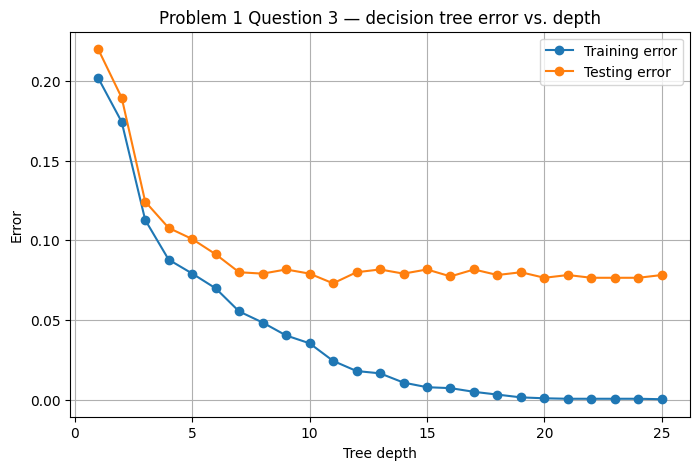

Problem 1 Question 3 — observations:
As depth increases, the training error should usually go down.
The testing error helps us see when the tree starts to overfit.
A good depth is often where the testing error is smallest or close to smallest.


In [ ]:
# prob 1b: limit tree depth so it doesnt memorize everything
depth_values = list(range(1, entropy_tree.get_depth() + 1))
depth_results = []

for depth in depth_values:
    depth_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=random_state)
    depth_tree.fit(X_train_spam, y_train_spam)

    train_metrics = get_binary_metrics(depth_tree, X_train_spam, y_train_spam)
    test_metrics = get_binary_metrics(depth_tree, X_test_spam, y_test_spam)

    depth_results.append({
        'depth': depth,
        'train_error': train_metrics['error'],
        'test_error': test_metrics['error'],
    })

depth_df = pd.DataFrame(depth_results)
# pick depth where test error is lowest (thats what we care about)
best_depth = int(depth_df.loc[depth_df['test_error'].idxmin(), 'depth'])

print('Problem 1 Question 3 — training vs testing error by depth (first 10 depths):')
print(depth_df.head(10).round(4).to_string(index=False))
print()
print('Problem 1 Question 3 — recommended depth (lowest test error):', best_depth)

# plot train vs test error i think gap = overfitting vibes
os.makedirs('hw4_figures', exist_ok=True)
plt.figure(figsize=(8, 5))
plt.plot(depth_df['depth'], depth_df['train_error'], marker='o', label='Training error')
plt.plot(depth_df['depth'], depth_df['test_error'], marker='o', label='Testing error')
plt.xlabel('Tree depth')
plt.ylabel('Error')
plt.title('Problem 1 Question 3 — decision tree error vs. depth')
plt.legend()
plt.grid(True)
plt.savefig('hw4_figures/problem1_depth.png', dpi=150, bbox_inches='tight')
plt.show()

print('Problem 1 Question 3 — observations:')
print('As depth increases, the training error should usually go down.')
print('The testing error helps us see when the tree starts to overfit.')
print('A good depth is often where the testing error is smallest or close to smallest.')


## Problem 2


In [ ]:
# prob 2: random forest, try diff # of trees
rf_tree_counts = [10, 50, 100, 500]
rf_models = {}  # save models so we can use best one later
rf_results = []

for n_trees in rf_tree_counts:
    rf_model = RandomForestClassifier(
        n_estimators=n_trees,
        criterion='gini',
        random_state=random_state,
        n_jobs=-1  # use all cpu cores bc im lazy to wait
    )
    rf_model.fit(X_train_spam, y_train_spam)
    rf_models[n_trees] = rf_model

    train_metrics = get_binary_metrics(rf_model, X_train_spam, y_train_spam)
    test_metrics = get_binary_metrics(rf_model, X_test_spam, y_test_spam)
#WHATS UP WITH THIS LINE THATS NO WORKING 
    rf_results.append({
        'n_trees': n_trees,
        'train_accuracy': train_metrics['accuracy'],
        'test_accuracy': test_metrics['accuracy'],
        'train_f1': train_metrics['f1'],
        'test_f1': test_metrics['f1'],
        'train_auc': train_metrics['auc'],
        'test_auc': test_metrics['auc'],
    })

rf_results_df = pd.DataFrame(rf_results)
print('Problem 2 Question 1 — Random Forest: accuracy, F1, AUC on train and test for T in {10, 50, 100, 500}:')
print(rf_results_df.round(4).to_string(index=False))
print()
print('Problem 2 Question 2 — observations (how metrics change as T increases):')
print('As the number of trees grows, the random forest usually becomes more stable.')
print('The testing metrics often improve at first and then level off.')


Problem 2 Question 1 — Random Forest: accuracy, F1, AUC on train and test for T in {10, 50, 100, 500}:
 n_trees  train_accuracy  test_accuracy  train_f1  test_f1  train_auc  test_auc
      10          0.9971         0.9418    0.9963   0.9241        1.0    0.9772
      50          0.9997         0.9470    0.9996   0.9311        1.0    0.9852
     100          0.9997         0.9513    0.9996   0.9371        1.0    0.9859
     500          0.9997         0.9513    0.9996   0.9368        1.0    0.9863

Problem 2 Question 2 — observations (how metrics change as T increases):
As the number of trees grows, the random forest usually becomes more stable.
The testing metrics often improve at first and then level off.


Problem 2 Question 3 — best Random Forest (by test AUC) vs Problem 1 decision trees:
Best random forest by test AUC uses 500 trees.
Best random forest test accuracy: 0.9513
Best random forest test F1: 0.9368
Best random forest test AUC: 0.9863

Problem 1 decision tree test accuracy (entropy): 0.9218
Problem 1 decision tree test accuracy (Gini): 0.9079
Observation: Random forest usually generalizes better because it averages many trees.

Problem 2 Question 4 — top 10 most important features (full bar plot is all features):
                   feature  importance
               char_freq_!      0.1203
               char_freq_$      0.1005
          word_freq_remove      0.0775
capital_run_length_average      0.0631
            word_freq_your      0.0578
capital_run_length_longest      0.0575
            word_freq_free      0.0569
  capital_run_length_total      0.0508
              word_freq_hp      0.0445
           word_freq_money      0.0339


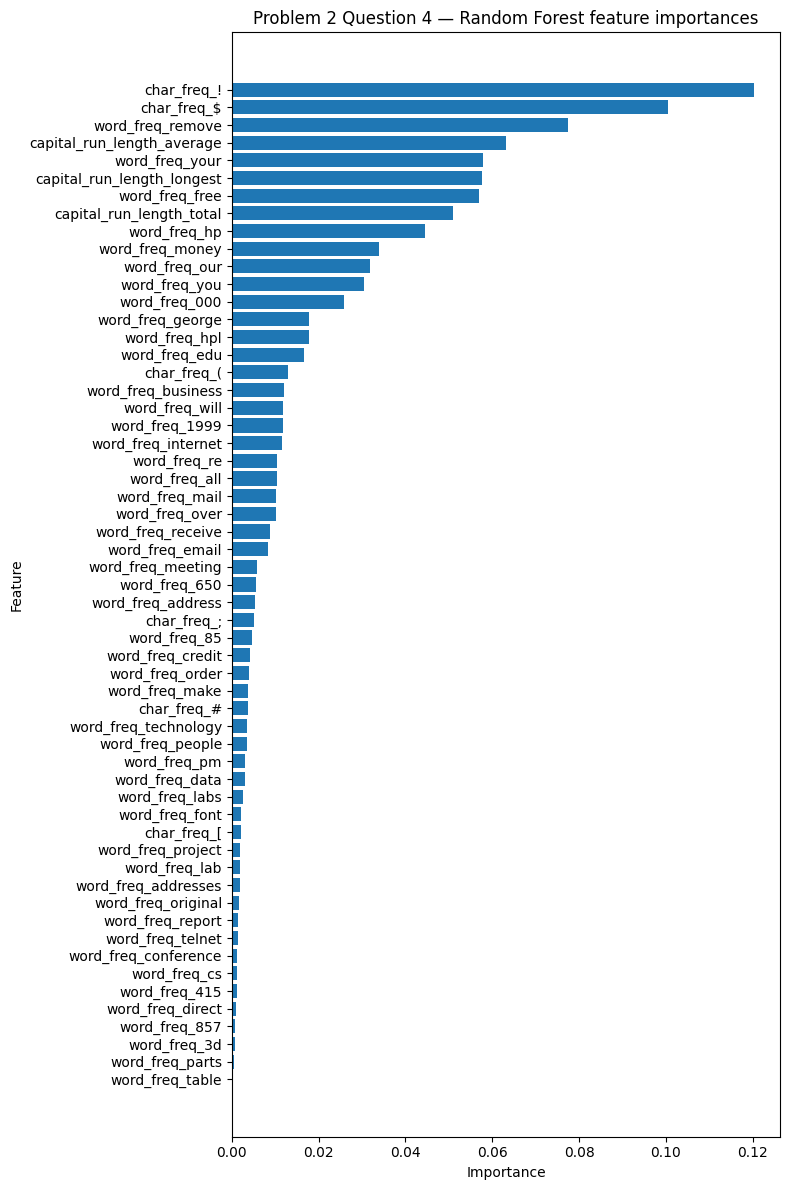

In [39]:
# best forest = highest test AUC (picked that metric idk)
best_rf_row = rf_results_df.loc[rf_results_df['test_auc'].idxmax()]
best_rf_trees = int(best_rf_row['n_trees'])
best_rf_model = rf_models[best_rf_trees]

print('Problem 2 Question 3 — best Random Forest (by test AUC) vs Problem 1 decision trees:')
print('Best random forest by test AUC uses', best_rf_trees, 'trees.')
print('Best random forest test accuracy:', round(best_rf_row['test_accuracy'], 4))
print('Best random forest test F1:', round(best_rf_row['test_f1'], 4))
print('Best random forest test AUC:', round(best_rf_row['test_auc'], 4))
print()
print('Problem 1 decision tree test accuracy (entropy):', round(entropy_test_metrics['accuracy'], 4))
print('Problem 1 decision tree test accuracy (Gini):', round(gini_test_metrics['accuracy'], 4))
print('Observation: Random forest usually generalizes better because it averages many trees.')

# which words matter most for spam (sklearn already computed this)
importance_df = pd.DataFrame({
    'feature': spambase_feature_names,
    'importance': best_rf_model.feature_importances_,
})
importance_df = importance_df.sort_values('importance')

print()
print('Problem 2 Question 4 — top 10 most important features (full bar plot is all features):')
print(importance_df.tail(10).sort_values('importance', ascending=False).round(4).to_string(index=False))

plt.figure(figsize=(8, 12))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Problem 2 Question 4 — Random Forest feature importances')
plt.tight_layout()
plt.savefig('hw4_figures/problem2_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Problem 3


In [ ]:
# prob 3: adaboost with stumps (depth 1 trees)
ada_tree_counts = [10, 50, 100, 500]
ada_models = {}
ada_results = []

for n_trees in ada_tree_counts:
    stump = DecisionTreeClassifier(max_depth=1, random_state=random_state)  # weak learner
    ada_model = AdaBoostClassifier(
        estimator=stump,
        n_estimators=n_trees,
        random_state=random_state
    )
    ada_model.fit(X_train_spam, y_train_spam)
    ada_models[n_trees] = ada_model

    train_metrics = get_binary_metrics(ada_model, X_train_spam, y_train_spam)
    test_metrics = get_binary_metrics(ada_model, X_test_spam, y_test_spam)

    ada_results.append({
        'n_estimators': n_trees,
        'train_accuracy': train_metrics['accuracy'],
        'test_accuracy': test_metrics['accuracy'],
        'train_f1': train_metrics['f1'],
        'test_f1': test_metrics['f1'],
        'train_auc': train_metrics['auc'],
        'test_auc': test_metrics['auc'],
    })

ada_results_df = pd.DataFrame(ada_results)
print('Problem 3 Question 1 — AdaBoost: accuracy, F1, AUC on train and test (base learner = decision tree stumps, max_depth=1).')
print(ada_results_df.round(4).to_string(index=False))


Problem 3 Question 1 — AdaBoost: accuracy, F1, AUC on train and test (base learner = decision tree stumps, max_depth=1).
 n_estimators  train_accuracy  test_accuracy  train_f1  test_f1  train_auc  test_auc
           10          0.9058         0.8914    0.8807   0.8616     0.9638    0.9545
           50          0.9348         0.9209    0.9156   0.8976     0.9814    0.9762
          100          0.9414         0.9314    0.9247   0.9117     0.9843    0.9789
          500          0.9522         0.9374    0.9387   0.9195     0.9902    0.9828


Problem 3 Question 2 — AdaBoost vs Random Forest (test metrics; train metrics are in the two tables above):
 n_learners  rf_test_accuracy  ada_test_accuracy  rf_test_f1  ada_test_f1  rf_test_auc  ada_test_auc
         10            0.9418             0.8914      0.9241       0.8616       0.9772        0.9545
         50            0.9470             0.9209      0.9311       0.8976       0.9852        0.9762
        100            0.9513             0.9314      0.9371       0.9117       0.9859        0.9789
        500            0.9513             0.9374      0.9368       0.9195       0.9863        0.9828

Problem 3 Question 2 — observations:
Random Forest and AdaBoost both improve over a single tree in many cases.
Looking at the test metrics is more useful than looking only at the training metrics.


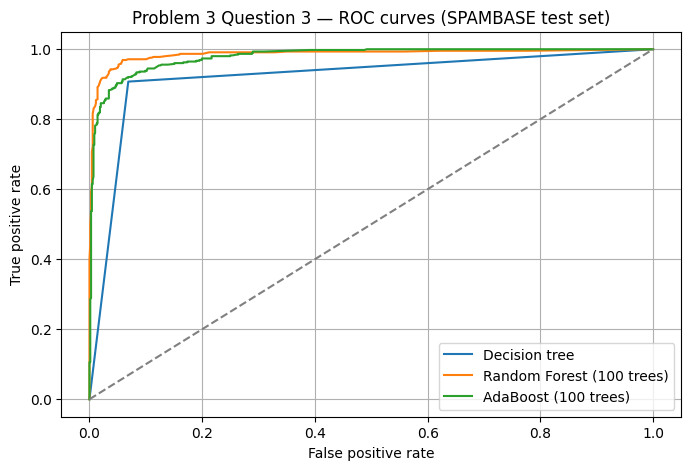

Problem 3 Question 3 — AUC from ROC curves (decision tree vs RF 100 vs AdaBoost 100 on test):
AUC — decision tree (Problem 1 entropy tree): 0.9193
AUC — Random Forest (100 trees): 0.9859
AUC — AdaBoost (100 trees): 0.9789


In [ ]:
# side by side rf vs ada for the homework table
comparison_rows = []

for n_trees in rf_tree_counts:
    rf_row = rf_results_df[rf_results_df['n_trees'] == n_trees].iloc[0]
    ada_row = ada_results_df[ada_results_df['n_estimators'] == n_trees].iloc[0]

    comparison_rows.append({
        'n_learners': n_trees,
        'rf_test_accuracy': rf_row['test_accuracy'],
        'ada_test_accuracy': ada_row['test_accuracy'],
        'rf_test_f1': rf_row['test_f1'],
        'ada_test_f1': ada_row['test_f1'],
        'rf_test_auc': rf_row['test_auc'],
        'ada_test_auc': ada_row['test_auc'],
    })

comparison_df = pd.DataFrame(comparison_rows)
print('Problem 3 Question 2 — AdaBoost vs Random Forest (test metrics; train metrics are in the two tables above):')
print(comparison_df.round(4).to_string(index=False))
print()
print('Problem 3 Question 2 — observations:')
print('Random Forest and AdaBoost both improve over a single tree in many cases.')
print('Looking at the test metrics is more useful than looking only at the training metrics.')

# ROC curves, need probs not just 0/1 labels
tree_probs = entropy_tree.predict_proba(X_test_spam)[:, 1]
rf_100_probs = rf_models[100].predict_proba(X_test_spam)[:, 1]
ada_100_probs = ada_models[100].predict_proba(X_test_spam)[:, 1]

tree_fpr, tree_tpr, _ = roc_curve(y_test_spam, tree_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test_spam, rf_100_probs)
ada_fpr, ada_tpr, _ = roc_curve(y_test_spam, ada_100_probs)

plt.figure(figsize=(8, 5))
plt.plot(tree_fpr, tree_tpr, label='Decision tree')
plt.plot(rf_fpr, rf_tpr, label='Random Forest (100 trees)')
plt.plot(ada_fpr, ada_tpr, label='AdaBoost (100 trees)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Problem 3 Question 3 — ROC curves (SPAMBASE test set)')
plt.legend()
plt.grid(True)
plt.savefig('hw4_figures/problem3_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print('Problem 3 Question 3 — AUC from ROC curves (decision tree vs RF 100 vs AdaBoost 100 on test):')
print('AUC — decision tree (Problem 1 entropy tree):', round(roc_auc_score(y_test_spam, tree_probs), 4))
print('AUC — Random Forest (100 trees):', round(roc_auc_score(y_test_spam, rf_100_probs), 4))
print('AUC — AdaBoost (100 trees):', round(roc_auc_score(y_test_spam, ada_100_probs), 4))


## Problem 4


In [ ]:
# prob 4: naive bayes by hand (no sklearn for training part)
# laplace +1 smoothing on counts bc zeros break stuff
def train_manual_naive_bayes(X_train, y_train, full_data):
    class_labels = sorted(y_train.unique())
    class_counts = {}
    priors = {}
    conditional_probabilities = {}
    feature_possible_values = {}

    total_rows = len(X_train)

    # need all possible values per feature from FULL data (test might have same categories)
    for column in X_train.columns:
        feature_possible_values[column] = sorted(full_data[column].unique())

    for class_label in class_labels:
        class_rows = X_train[y_train == class_label]
        class_counts[class_label] = len(class_rows)
        priors[class_label] = len(class_rows) / total_rows  # P(class)
        conditional_probabilities[class_label] = {}

        for column in X_train.columns:
            possible_values = feature_possible_values[column]
            denominator = len(class_rows) + len(possible_values)  # +K for laplace
            conditional_probabilities[class_label][column] = {}

            for value in possible_values:
                count = (class_rows[column] == value).sum()
                conditional_probabilities[class_label][column][value] = (count + 1) / denominator  # P(x|y)

    return priors, conditional_probabilities, feature_possible_values, class_counts

# multiply probs so use log probs so numbers dont underflow to 0
def predict_manual_naive_bayes(X_test, priors, conditional_probabilities, feature_possible_values, class_counts):
    predictions = []
    probability_rows = []
    class_labels = sorted(priors.keys())

    for _, row in X_test.iterrows():
        log_scores = {}

        for class_label in class_labels:
            log_score = np.log(priors[class_label])

            for column in X_test.columns:
                value = row[column]
                denominator = class_counts[class_label] + len(feature_possible_values[column])

                if value in conditional_probabilities[class_label][column]:
                    probability = conditional_probabilities[class_label][column][value]
                else:
                    probability = 1 / denominator  # never saw this value in train for this class

                log_score = log_score + np.log(probability)

            log_scores[class_label] = log_score

        predicted_label = max(log_scores, key=log_scores.get)  # bigger log = more likely
        predictions.append(predicted_label)

        # softmax-ish thing to get actual probs for the printout (subtract max for stability)
        largest_log_score = max(log_scores.values())
        scaled_values = {}
        total_scaled = 0

        for class_label in class_labels:
            scaled_value = np.exp(log_scores[class_label] - largest_log_score)
            scaled_values[class_label] = scaled_value
            total_scaled = total_scaled + scaled_value

        probability_rows.append({
            'e': scaled_values['e'] / total_scaled,
            'p': scaled_values['p'] / total_scaled,
        })

    return predictions, probability_rows


In [43]:
# train on mushroom train set, use full X for possible categories
manual_priors, conditional_probabilities, feature_possible_values, class_counts = train_manual_naive_bayes(
    X_train_mushroom,
    y_train_mushroom,
    X_mushroom
)

# predict test rows
manual_predictions_list, manual_probability_rows = predict_manual_naive_bayes(
    X_test_mushroom,
    manual_priors,
    conditional_probabilities,
    feature_possible_values,
    class_counts
)

manual_predictions = pd.Series(manual_predictions_list, index=y_test_mushroom.index)
manual_metrics = get_mushroom_metrics(y_test_mushroom, manual_predictions)
manual_probability_df = pd.DataFrame(manual_probability_rows)  # probs for screenshots / report
manual_probability_df = manual_probability_df.rename(columns={'e': 'P(Edible)', 'p': 'P(Poisonous)'})

print('Problem 4 Question 1 — priors P(Edible), P(Poisonous) and Laplace-smoothed P(X_i | Y) (example: odor):')
print('P(Edible) =', round(manual_priors['e'], 4))
print('P(Poisonous) =', round(manual_priors['p'], 4))
print()
print('Example conditional probabilities for the feature odor:')
print('Edible:', conditional_probabilities['e']['odor'])
print('Poisonous:', conditional_probabilities['p']['odor'])
print()
print('The full conditional probability table is stored in the variable conditional_probabilities.')
print()
print('Problem 4 Question 2 — estimated P(Edible) and P(Poisonous) per test row (first 5 rows):')
print(manual_probability_df.head().round(4).to_string(index=False))
print()
print_mushroom_metrics('Problem 4 Question 3 — accuracy, precision, recall, F1 (manual Naive Bayes on test)', manual_metrics)


Problem 4 Question 1 — priors P(Edible), P(Poisonous) and Laplace-smoothed P(X_i | Y) (example: odor):
P(Edible) = 0.518
P(Poisonous) = 0.482

Example conditional probabilities for the feature odor:
Edible: {'a': 0.09194312796208531, 'c': 0.000315955766192733, 'f': 0.000315955766192733, 'l': 0.09447077409162717, 'm': 0.000315955766192733, 'n': 0.8116903633491311, 'p': 0.000315955766192733, 's': 0.000315955766192733, 'y': 0.000315955766192733}
Poisonous: {'a': 0.00033944331296673454, 'c': 0.048879837067209775, 'f': 0.5577053632043448, 'l': 0.00033944331296673454, 'm': 0.009504412763068567, 'n': 0.032247114731839784, 'p': 0.06347589952477936, 's': 0.14086897488119485, 'y': 0.14663951120162932}

The full conditional probability table is stored in the variable conditional_probabilities.

Problem 4 Question 2 — estimated P(Edible) and P(Poisonous) per test row (first 5 rows):
 P(Edible)  P(Poisonous)
    1.0000        0.0000
    0.0000        1.0000
    1.0000        0.0000
    0.9795      

In [ ]:

all_categories = []
for column in mushroom_feature_names:
    all_categories.append(sorted(mushroom_df[column].unique()))

encoder = OrdinalEncoder(categories=all_categories)
X_train_mushroom_encoded = encoder.fit_transform(X_train_mushroom).astype(int)
X_test_mushroom_encoded = encoder.transform(X_test_mushroom).astype(int)

label_map = {'e': 0, 'p': 1}
reverse_label_map = {0: 'e', 1: 'p'}

y_train_mushroom_encoded = y_train_mushroom.map(label_map).astype(int)

# alpha=1 matches +1 smoothing like our manual version (i think)
package_nb = CategoricalNB(alpha=1.0)
package_nb.fit(X_train_mushroom_encoded, y_train_mushroom_encoded)

package_predictions_encoded = package_nb.predict(X_test_mushroom_encoded)
package_predictions = pd.Series(package_predictions_encoded, index=y_test_mushroom.index).map(reverse_label_map)
package_probabilities = package_nb.predict_proba(X_test_mushroom_encoded)[:, 1]  # col 1 = poisonous prob

package_metrics = {
    'accuracy': accuracy_score(y_test_mushroom, package_predictions),
    'precision': precision_score(y_test_mushroom, package_predictions, pos_label='p'),
    'recall': recall_score(y_test_mushroom, package_predictions, pos_label='p'),
    'f1': f1_score(y_test_mushroom, package_predictions, pos_label='p'),
}

print_mushroom_metrics('Problem 4 Question 4 — CategoricalNB (same train/test split as manual NB)', package_metrics)
print('Problem 4 Question 4 — first 5 package probabilities for poisonous (class p):')
print(pd.Series(package_probabilities).head().round(4).to_string(index=False))


Problem 4 Question 4 — CategoricalNB (same train/test split as manual NB)
Accuracy: 0.9527
Precision: 0.9911
Recall: 0.9101
F1 score: 0.9489

Problem 4 Question 4 — first 5 package probabilities for poisonous (class p):
0.0000
1.0000
0.0000
0.0205
1.0000


In [45]:
# compare manual vs sklearn on same test set
comparison_table = pd.DataFrame([
    {
        'model': 'Manual Naive Bayes',
        'accuracy': manual_metrics['accuracy'],
        'precision': manual_metrics['precision'],
        'recall': manual_metrics['recall'],
        'f1': manual_metrics['f1'],
    },
    {
        'model': 'CategoricalNB',
        'accuracy': package_metrics['accuracy'],
        'precision': package_metrics['precision'],
        'recall': package_metrics['recall'],
        'f1': package_metrics['f1'],
    },
])

print('Problem 4 Question 4 — manual Naive Bayes vs sklearn CategoricalNB (same metrics on test):')
print(comparison_table.round(4).to_string(index=False))
print()
print('Problem 4 Question 4 — observations (similar or different?):')
print('If the two models are close, that means the manual implementation is working similarly to the package version.')
print('Small differences can happen because of implementation details or how probabilities are handled internally.')


Problem 4 Question 4 — manual Naive Bayes vs sklearn CategoricalNB (same metrics on test):
             model  accuracy  precision  recall     f1
Manual Naive Bayes    0.9527     0.9911  0.9101 0.9489
     CategoricalNB    0.9527     0.9911  0.9101 0.9489

Problem 4 Question 4 — observations (similar or different?):
If the two models are close, that means the manual implementation is working similarly to the package version.
Small differences can happen because of implementation details or how probabilities are handled internally.
